In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_Biweekly_2010-2021_filled.csv', encoding=enc)


In [4]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,2009-12-07,40.659996,22.397246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.659996,22.397246,14192.0,14017.0,40.659996,22.397246,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,2010-01-01,40.650186,22.350102,0.019869,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.019869,0.019869
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,2009-12-07,40.659996,22.397246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.659996,22.397246,14129.0,13839.0,40.659996,22.397246,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,2010-01-16,40.650186,22.350102,21.994516,2010-01-09,2010-01-02,2010-01-09,2010-01-02,1.172702,21.024027
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,2009-12-07,40.677962,22.464619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.677962,22.464619,14251.0,13995.0,40.677962,22.464619,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,2010-01-01,40.650186,22.450103,0.021185,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.021185,0.021185
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,2009-12-07,40.677962,22.464619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,40.677962,22.464619,14188.0,13820.0,40.677962,22.464619,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,2010-01-16,40.650186,22.450103,19.148625,2010-01-09,2010-01-02,2010-01-09,2010-01-02,1.418397,18.804765
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,2009-12-07,40.624063,22.491569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,40.624063,22.491569,14239.0,14024.0,40.624063,22.491569,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,2010-01-01,40.650186,22.450103,0.021185,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.021185,0.021185


In [5]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [6]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [7]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [8]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14192.0,14017.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,0.019869,0.019869,0.019869
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39544,40.65816,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14129.0,13839.0,14034.000000,13884.285714,14232.000000,13736.916667,14665.866667,13888.352941,15154.230769,14149.636364,21.994516,1.172702,21.024027
2,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14251.0,13995.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,0.021185,0.021185,0.021185
3,αλεξανδρειας,κεντρικης μακεδονιας,22.46627,40.67612,2010-01-16,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14188.0,13820.0,13991.166667,13808.142857,14132.333333,13747.000000,14621.000000,13863.266667,15156.538462,14108.230769,19.148625,1.418397,18.804765
4,αλεξανδρειας,κεντρικης μακεδονιας,22.48988,40.62222,2010-01-01,2010,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14239.0,14024.0,14020.000000,13876.500000,14157.333333,13762.727273,14546.416667,13868.470588,15075.142857,14133.833333,0.021185,0.021185,0.021185


In [9]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2010-01-01,αλεξανδρειας,κεντρικης μακεδονιας,22.483978,40.644680,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14254.250000,13999.75,14038.416667,13841.023810,14155.566667,13756.638258,14594.434470,13873.434314,15130.728022,14121.996545,0.015560,0.015560,0.015560
1,2010-01-01,αλμωπιας,κεντρικης μακεδονιας,21.940791,40.977027,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14223.727273,13957.00,13869.513312,13744.208815,13867.496753,13711.131484,14224.720029,13763.856185,14598.699282,13988.568853,0.248551,0.248551,0.248551
2,2010-01-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14331.000000,14102.00,14294.000000,13933.000000,14150.166667,13838.100000,14571.111111,13959.833333,14996.000000,14245.000000,0.000000,0.000000,0.000000
3,2010-01-01,αμφιπολης,κεντρικης μακεδονιας,23.982527,40.915102,2010.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14313.500000,14075.75,14060.466667,13849.123810,14119.082323,13755.281926,14385.038636,13831.014839,14687.678342,14072.125000,0.055994,0.055994,0.055994
4,2010-01-01,αριστοτελη,κεντρικης μακεδονιας,23.691080,40.495934,2010.0,1.0,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.000000,0.000000,0.000000,0.000000,14419.500000,14040.25,14128.136995,13903.784226,14068.485978,13793.050847,14424.248689,13827.634516,14601.602841,14032.383996,1.750566,1.750566,1.750566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,2021-12-16,σιθωνιας,κεντρικης μακεδονιας,23.828106,40.110264,2021.0,12.0,0.533019,0.216610,-0.406977,-0.216610,0.525750,0.209897,-0.401147,-0.209897,0.039324,0.061157,0.034067,0.061157,NaN,NaN,14131.712105,13798.223434,14309.703516,13947.082353,14391.596265,13919.650000,14628.870760,14012.311944,2180.544076,75.411011,161.899452
10940,2021-12-16,σιντικης,κεντρικης μακεδονιας,23.388058,41.313484,2021.0,12.0,0.126568,-0.005089,-0.091934,0.005089,0.122184,0.074416,-0.090676,-0.074416,0.027041,0.050254,0.035247,0.050254,NaN,NaN,13895.539899,13525.684019,14245.385339,13792.929034,14454.229025,13724.788455,14684.146065,13885.721902,1562.784564,141.524710,215.682589
10941,2021-12-16,σκυδρας,κεντρικης μακεδονιας,22.146700,40.822940,2021.0,12.0,0.424823,0.260152,-0.272072,-0.260152,0.423505,0.247285,-0.273696,-0.247285,0.023733,0.043566,0.046055,0.043566,NaN,NaN,14058.867424,13572.800000,14466.912879,13843.509211,14590.182353,13825.676471,14830.247917,13975.117647,997.526490,56.599638,67.029917
10942,2021-12-16,χαλκηδονος,κεντρικης μακεδονιας,22.723020,40.753567,2021.0,12.0,0.255928,-0.052975,-0.231818,0.052975,0.276006,-0.030417,-0.240922,0.030417,0.059156,0.056067,0.041252,0.056067,NaN,NaN,14117.840476,13553.251852,14456.092308,13851.944444,14692.609280,13852.974401,14831.047863,14012.847619,1117.097203,59.682183,90.624163


In [10]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [11]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [12]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [13]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [14]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [15]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [16]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [17]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


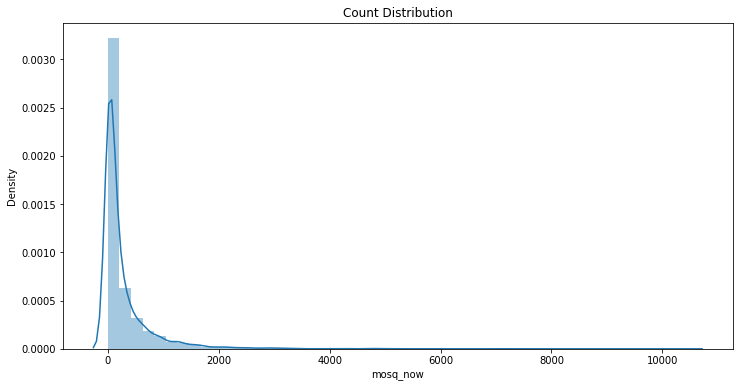

In [18]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [19]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

C:\Users\dimit\AppData\Local\Temp/ipykernel_8980/187358562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


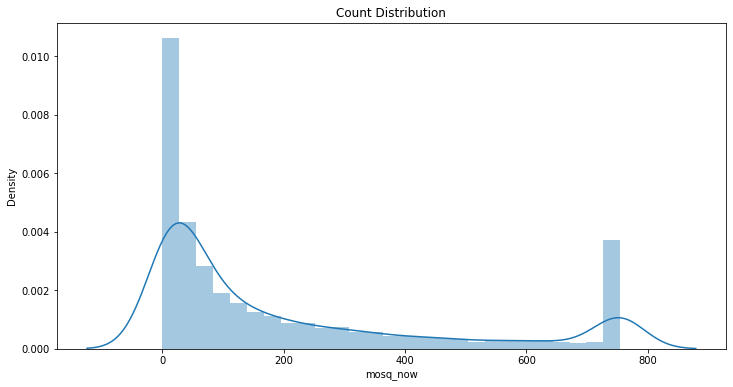

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

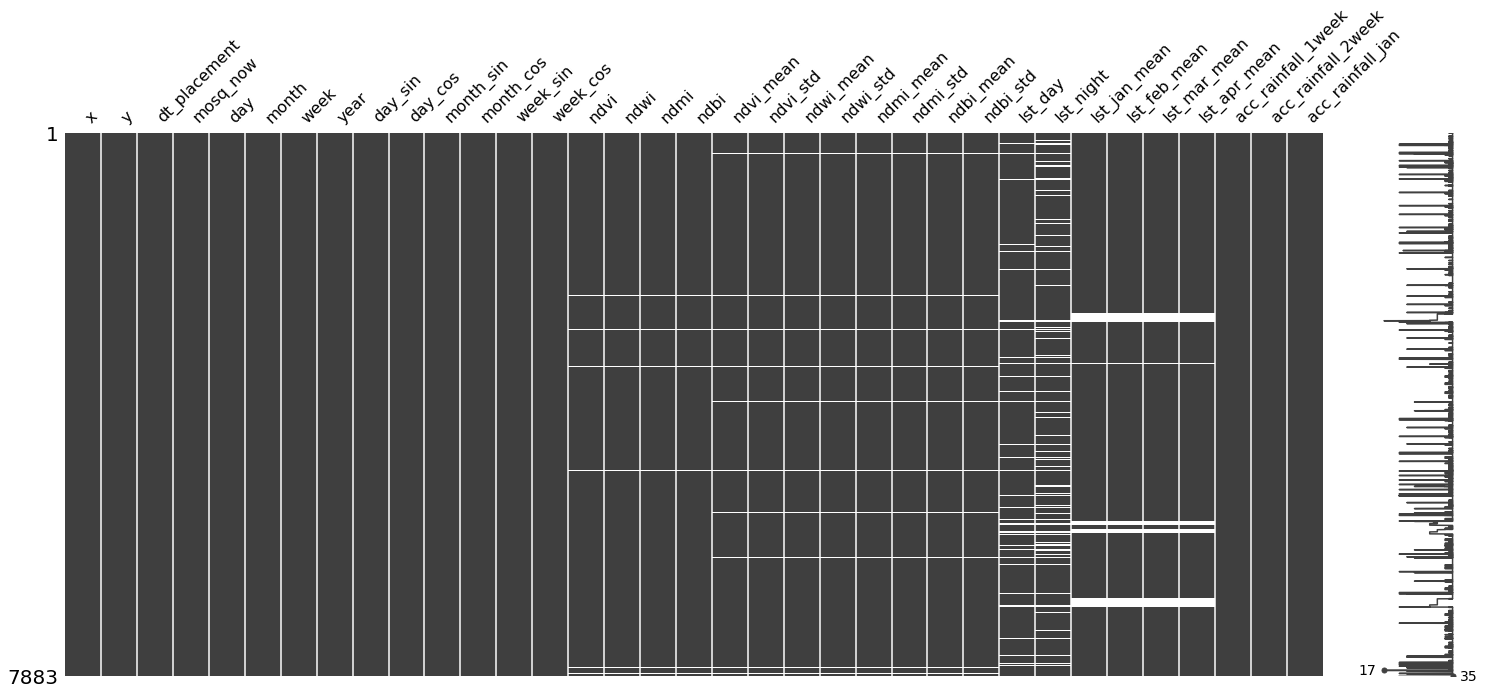

In [21]:
missingno.matrix(mosquito_data_nuts2)

In [22]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [23]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

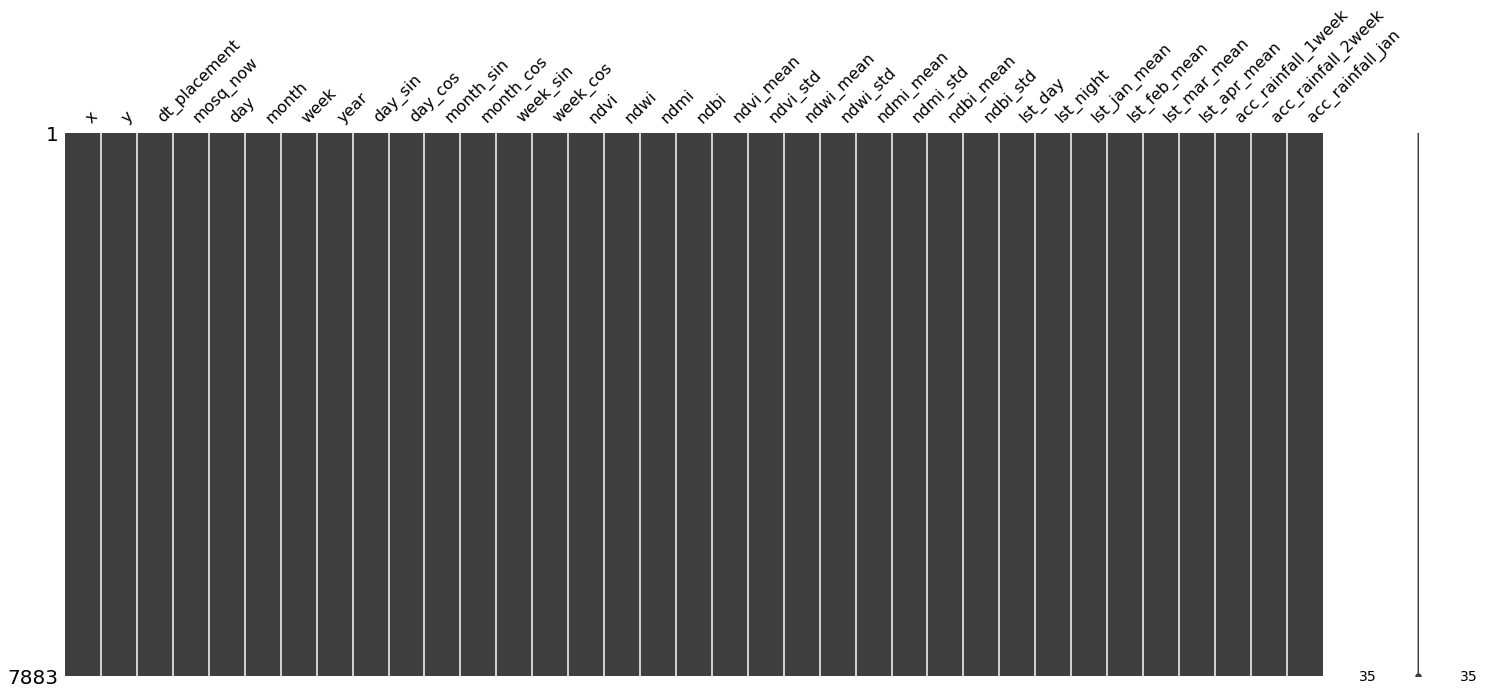

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [26]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\indexing.py:1667: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value


In [27]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 20.23446 | Val Loss: 23.62586 | Train Acc: 2.763| Val Acc: 2.482
Epoch 002: | Train Loss: 18.32360 | Val Loss: 25.25307 | Train Acc: 2.187| Val Acc: 2.092
Epoch 003: | Train Loss: 18.51816 | Val Loss: 25.71894 | Train Acc: 2.255| Val Acc: 2.119
Epoch 004: | Train Loss: 18.36262 | Val Loss: 25.09647 | Train Acc: 2.207| Val Acc: 2.053
Epoch 005: | Train Loss: 18.15464 | Val Loss: 23.64172 | Train Acc: 2.158| Val Acc: 2.034
Epoch 006: | Train Loss: 17.66086 | Val Loss: 23.85744 | Train Acc: 2.072| Val Acc: 1.975
Epoch 007: | Train Loss: 17.64949 | Val Loss: 23.49626 | Train Acc: 2.086| Val Acc: 2.052
Epoch 008: | Train Loss: 17.30246 | Val Loss: 23.49417 | Train Acc: 2.027| Val Acc: 2.014
Epoch 009: | Train Loss: 17.15583 | Val Loss: 23.20933 | Train Acc: 2.012| Val Acc: 2.028
Epoch 010: | Train Loss: 16.75365 | Val Loss: 23.84811 | Train Acc: 1.981| Val Acc: 2.038
Epoch 011: | Train Loss: 16.91002 | Val Loss: 23.72694 | Train Acc: 2.000| Val Acc: 2.049
Epoch 012:

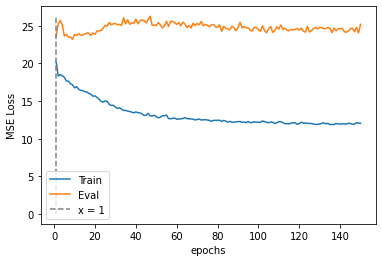

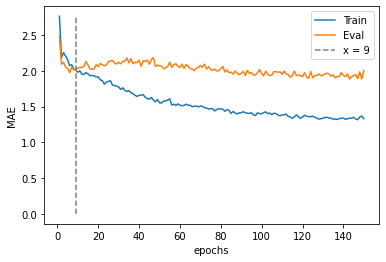

In [28]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [29]:
metrics(train, test, threshold=30)

MAE on train set:  139.43201189435
min prediction: 1
max prediction: 1309

MAE on test set:  166.1642902427648
Error ⩽ 30: 17.85 %
min prediction: 1
max prediction: 1402


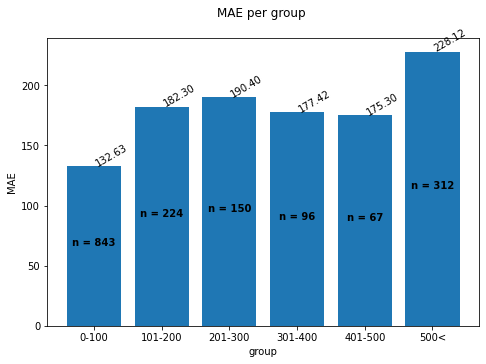

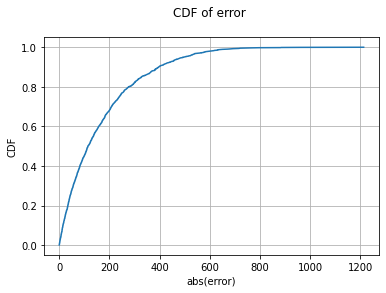

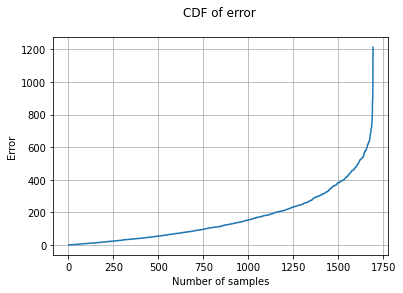

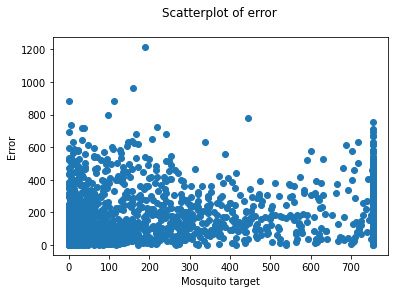

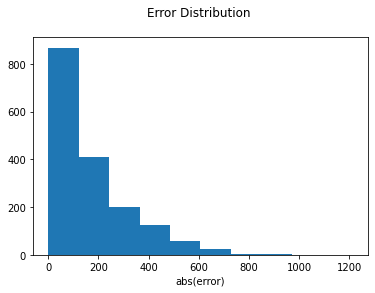

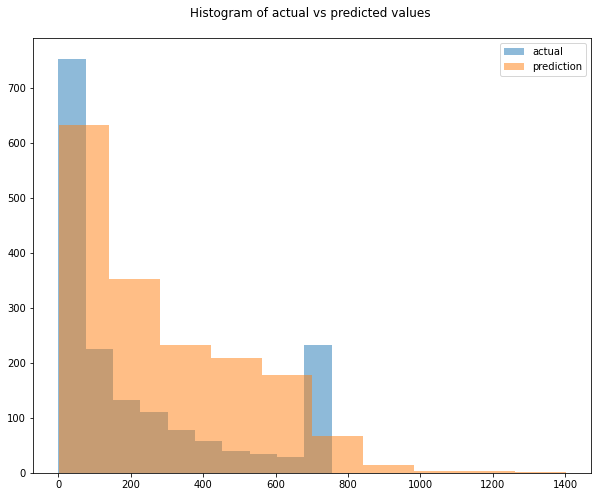

In [30]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.58200 | Val Loss: 5.44811 | Train Acc: 1.531| Val Acc: 2.633
Epoch 002: | Train Loss: 13.51469 | Val Loss: 4.23104 | Train Acc: 1.548| Val Acc: 1.633
Epoch 003: | Train Loss: 13.45262 | Val Loss: 7.51167 | Train Acc: 1.527| Val Acc: 2.633
Epoch 004: | Train Loss: 13.39535 | Val Loss: 4.85290 | Train Acc: 1.535| Val Acc: 2.633
Epoch 005: | Train Loss: 13.33384 | Val Loss: 4.40904 | Train Acc: 1.496| Val Acc: 1.633
Epoch 006: | Train Loss: 13.18559 | Val Loss: 5.46837 | Train Acc: 1.503| Val Acc: 2.633
Epoch 007: | Train Loss: 13.23279 | Val Loss: 6.46572 | Train Acc: 1.506| Val Acc: 2.633
Epoch 008: | Train Loss: 13.15452 | Val Loss: 6.14055 | Train Acc: 1.502| Val Acc: 2.633
Epoch 009: | Train Loss: 12.98455 | Val Loss: 5.94369 | Train Acc: 1.450| Val Acc: 2.633
Epoch 010: | Train Loss: 13.04998 | Val Loss: 6.05979 | Train Acc: 1.485| Val Acc: 2.633
Epoch 011: | Train Loss: 13.03392 | Val Loss: 5.72294 | Train Acc: 1.473| Val Acc: 2.633
Epoch 012: | Train Lo

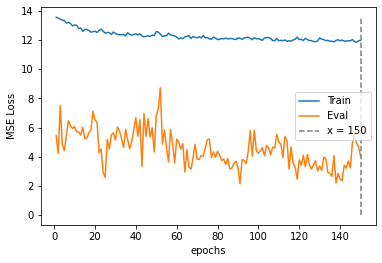

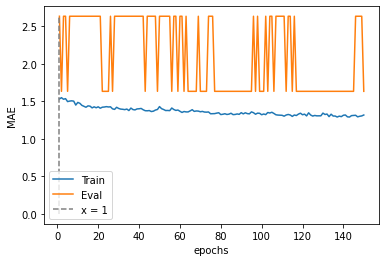

In [31]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [33]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [34]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [35]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [36]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [37]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

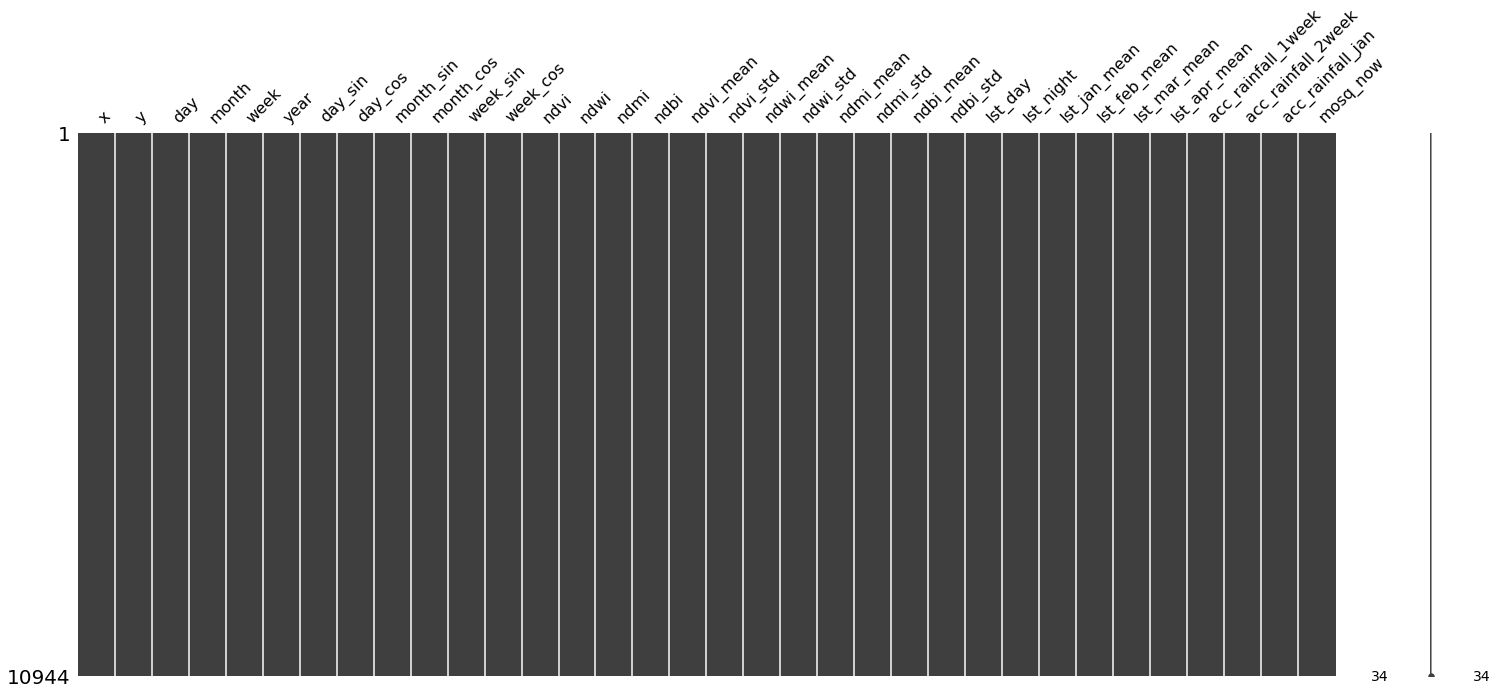

In [38]:
missingno.matrix(dataset_mamoth)

In [39]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [40]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [41]:
predictions = give_predictions(model, dataset_mamoth)

In [42]:
mosqutio_predictions['mosq_pred'] = predictions

In [43]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.483978,40.644680,2010-01-01,5
1,21.940791,40.977027,2010-01-01,2
2,22.891980,40.656030,2010-01-01,7
3,23.982527,40.915102,2010-01-01,1
4,23.691080,40.495934,2010-01-01,4
...,...,...,...,...
10939,23.828106,40.110264,2021-12-16,2
10940,23.388058,41.313484,2021-12-16,1
10941,22.146700,40.822940,2021-12-16,1
10942,22.723020,40.753567,2021-12-16,1


In [44]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2021.csv', index = False)